<a href="https://colab.research.google.com/github/kevin-ehab/Medical-Urgency-AI-Model/blob/main/model_preparation_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import  pandas  as  pd
df = pd.read_csv ( 'data.csv' ,  encoding= 'latin1' ,  sep= ';' )
df.sample ( 5 )

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
996,2,1,56,9,3,1,Urticarial rash,1,0,#BOÞ!,...,36.6,97,4,Allergic urticaria,1,4,0,7800,"3,00",0
1228,2,2,50,6,2,1,Rt. flank pain,1,1,3,...,36.3,98,4,Ureteric stone,1,4,0,766,"3,00",0
147,2,1,45,3,3,1,chest palpitation,1,0,#BOÞ!,...,36,98,4,Panic attack,1,3,3,386,"3,00",2
758,1,2,37,5,2,1,"pain, chest",1,1,10,...,36.3,NaN,2,Chest pain,2,2,0,552,"4,68",0
1205,2,1,89,10,4,1,melena,1,0,#BOÞ!,...,36.3,97,2,"Gastrointestinal haemorrhage, unspecified",2,2,0,9485,"2,00",0


In [ ]:
columns_to_check = ["Age", "SBP", "DBP", "HR",
                    "RR", "BT", "NRS_pain", "KTAS_RN","Sex",
                    "Injury", "Mental", "Pain"]
for col in columns_to_check:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 30)

Unique values in 'Age':
[71 56 68 58 54 49 78 32 38 43 45 53 55 65 69 20 79 24 59 77 37 62 74 44
 16 19 27 30 47 48 87 21 34 36 52 70 81 89 39 29 64 72 83 23 25 26 22 82
 33 61 75 18 42 66 76 85 73 84 50 28 60 67 80 90 92 57 88 63 35 46 17 31
 40 41 51 86 94 91 93 95 96]
------------------------------
Unique values in 'SBP':
['160' '137' '130' '139' '91' '140' '110' '169' '148' '141' '120' '121'
 '135' '100' '133' '124' '118' '80' '180' '125' '162' '116' '152' '164'
 '196' '144' '150' '200' '113' '119' '156' '165' '132' '??' '199' '138'
 '176' '170' '136' '194' '122' '214' '178' '108' '50' '145' '142' '210'
 '143' '65' '129' '123' '158' '187' '96' '70' '102' '161' '90' '105' '190'
 '151' '134' '106' '149' '189' '197' '155' '131' '168' '166' '126' '115'
 '128' '114' '153' '117' '101' '159' '109' '157' '182' '111' '163' '167'
 '127' '147' '154' '112' '179' '191' '93' '98' '198' '204' '177' '195'
 '107' '171' '183' '146' '95' '202' '174' '86' '94' '181' '75' '211' '173'
 '193' '205' '99' 

In [ ]:
df["Emergency"] = (df["KTAS_RN"] <= 3).astype(int)

In [ ]:
mask = (df['HR']!='??') & (df['RR']!='??') & (df['BT']!='??') & (df['SBP']!='??') & (df['DBP']!='??')
df = df[mask]

In [ ]:
median = df[df['NRS_pain'].str.isnumeric()]['NRS_pain'].astype(int).median()
df['NRS_pain'] = df['NRS_pain'].str.replace('#BOÞ!', str(median)).astype(float)
df[["Age", "SBP", "DBP", "HR", "RR", "BT", "NRS_pain"]]=df[["Age", "SBP", "DBP", "HR", "RR", "BT", "NRS_pain"]].astype(float)

,Age,SBP,DBP,HR,RR,BT,NRS_pain
0,71.0,160.0,100.0,84.0,18.0,36.6,2.0
1,56.0,137.0,75.0,60.0,20.0,36.5,2.0
2,68.0,130.0,80.0,102.0,20.0,36.6,2.0
3,71.0,139.0,94.0,88.0,20.0,36.5,3.0
4,58.0,91.0,67.0,93.0,18.0,36.5,3.0
...,...,...,...,...,...,...,...
1262,79.0,120.0,80.0,86.0,22.0,36.4,4.0
1263,81.0,120.0,80.0,94.0,20.0,36.4,4.0
1264,81.0,130.0,90.0,80.0,20.0,36.2,4.0
1265,81.0,170.0,100.0,78.0,20.0,36.6,4.0


In [ ]:
num_x = ["Age", "SBP", "DBP", "HR", "RR", "BT", "NRS_pain"]
cat_x = ["Sex", "Injury", "Mental", "Pain", "Chief_complain"]
x= df[num_x + cat_x]
y = df["Emergency"]
df[num_x+cat_x+["Emergency"]]

,Age,SBP,DBP,HR,RR,BT,NRS_pain,Sex,Injury,Mental,Pain,Chief_complain,Emergency
0,71,160,100,84,18,36.6,2.0,2,2,1,1,right ocular pain,1
1,56,137,75,60,20,36.5,2.0,1,2,1,1,right forearm burn,0
2,68,130,80,102,20,36.6,2.0,1,2,1,1,"arm pain, Lt",0
3,71,139,94,88,20,36.5,3.0,2,1,1,1,ascites tapping,0
4,58,91,67,93,18,36.5,3.0,2,1,1,1,"distension, abd",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,79,120,80,86,22,36.4,4.0,2,1,1,0,mental change,1
1263,81,120,80,94,20,36.4,4.0,2,1,1,0,dysuria,0
1264,81,130,90,80,20,36.2,4.0,2,1,1,0,dizziness,1
1265,81,170,100,78,20,36.6,4.0,1,2,1,0,"Sensory, Decreased",1


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_x),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_x)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

In [ ]:
param_grid = {
      'classifier__C': [0.1, 1, 10, 100],
      'classifier__gamma': ['scale', 0.01, 0.1, 1]
}
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'SBP',
                                                                          'DBP',
                                                                          'HR',
                                                                          'RR',
                                                                          'BT',
                                                                          'NRS_pain']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Injury',
                                                                          'Mental',
                                                                          'Pain',
                                                                          'Chief_complain'])])),
                                       ('classifier', SVC())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10, 100],
                         'classifier__gamma': ['scale', 0.01, 0.1, 1]},
             scoring='f1')

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(x_test)
results = pd.DataFrame({
  'y_test': y_test,
  'y_pred': y_pred
})
results

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,y_test,y_pred
368,1,1
559,1,1
818,1,1
49,1,1
996,0,0
...,...,...
536,1,0
739,1,1
357,0,0
623,1,1


In [ ]:
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix, recall_score,
                             f1_score,
                             ConfusionMatrixDisplay)
print('accuracy: ', accuracy_score(y_test, y_pred))
print('recall: ', recall_score(y_test, y_pred))
print('f1 score: ', f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy:  0.8178137651821862
recall:  0.8125
f1 score:  0.8221343873517787
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       119
           1       0.83      0.81      0.82       128

    accuracy                           0.82       247
   macro avg       0.82      0.82      0.82       247
weighted avg       0.82      0.82      0.82       247



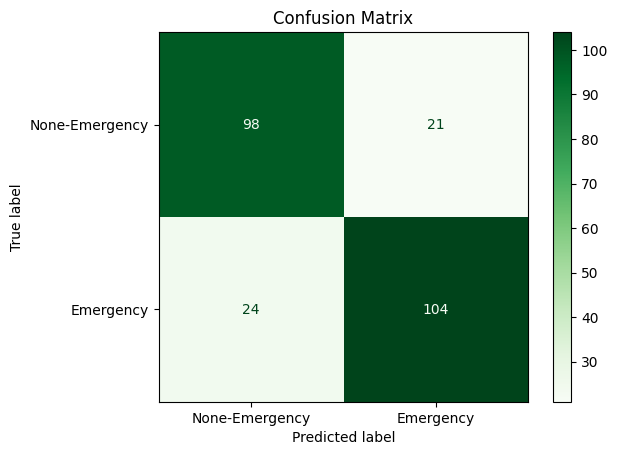

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["None-Emergency", "Emergency"]
)
import matplotlib.pyplot as plt

disp.plot(cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']